# Emotion Classification with BERT

This notebook demonstrates how to build an emotion classifier using BERT (Bidirectional Encoder Representations from Transformers) for text classification. We'll train a model to classify text into 6 different emotions: anger, fear, joy, love, sadness, and surprise.

## Table of Contents
1. [Setup and Imports](#1-setup-and-imports)
2. [Data Loading and Preprocessing](#2-data-loading-and-preprocessing)
3. [BERT Tokenization](#3-bert-tokenization)
4. [Model Architecture](#4-model-architecture)
5. [Training](#5-training)
6. [Evaluation](#6-evaluation)
7. [Prediction Examples](#7-prediction-examples)

---

## 1. Setup and Imports

In [24]:
%%capture
# Install required packages
!pip install -qq transformers

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

import torch
from torch import nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

from transformers import BertModel, AutoTokenizer, get_linear_schedule_with_warmup
from collections import defaultdict

print("All libraries imported successfully!")

In [25]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

## 2. Data Loading and Preprocessing

In this section, we'll load our emotion dataset and perform necessary preprocessing steps including label encoding and data exploration.

### 2.1 Load Dataset

We'll load three datasets:
- **Training set**: Used to train the model
- **Validation set**: Used to monitor training progress and prevent overfitting
- **Test set**: Used for final evaluation

In [26]:
df = pd.read_csv("/kaggle/input/emotions-dataset-for-nlp/train.txt",
                 delimiter=';', header=None, names=['sentence','label'])

val_df = pd.read_csv("/kaggle/input/emotions-dataset-for-nlp/val.txt",
                 delimiter=';', header=None, names=['sentence','label'])

ts_df = pd.read_csv("/kaggle/input/emotions-dataset-for-nlp/test.txt",
                 delimiter=';', header=None, names=['sentence','label'])

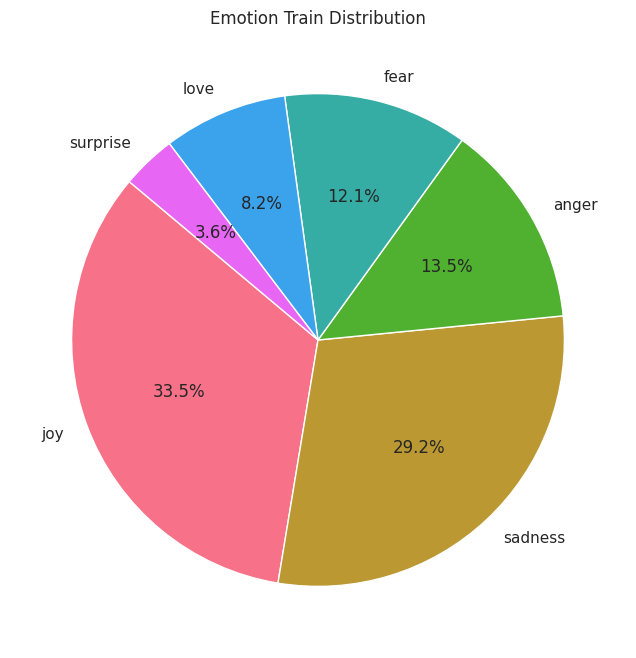

In [27]:
# Count label distributions
label_counts = df['label'].value_counts()
light_colors = sns.husl_palette(n_colors=len(label_counts))
sns.set(style="whitegrid")
plt.figure(figsize=(8, 8))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=140, colors=light_colors)
plt.title('Emotion Train Distribution')
plt.show()

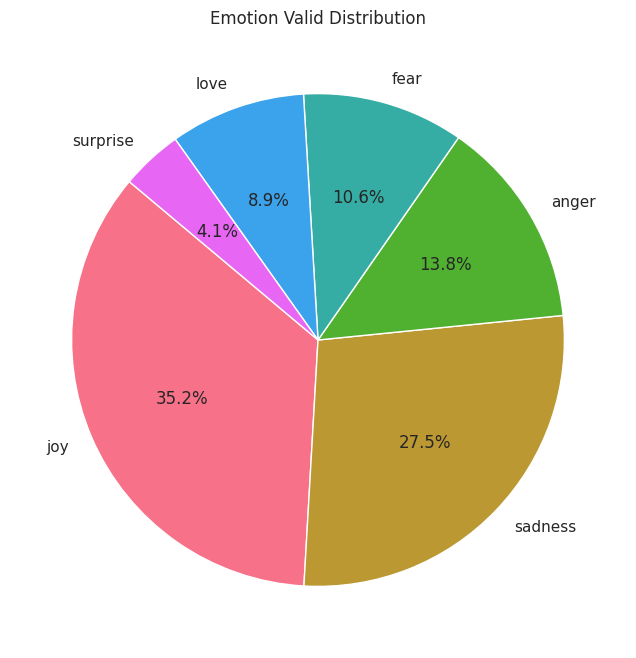

In [28]:
label_counts = val_df['label'].value_counts()
light_colors = sns.husl_palette(n_colors=len(label_counts))
sns.set(style="whitegrid")
plt.figure(figsize=(8, 8))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=140, colors=light_colors)
plt.title('Emotion Valid Distribution')
plt.show()

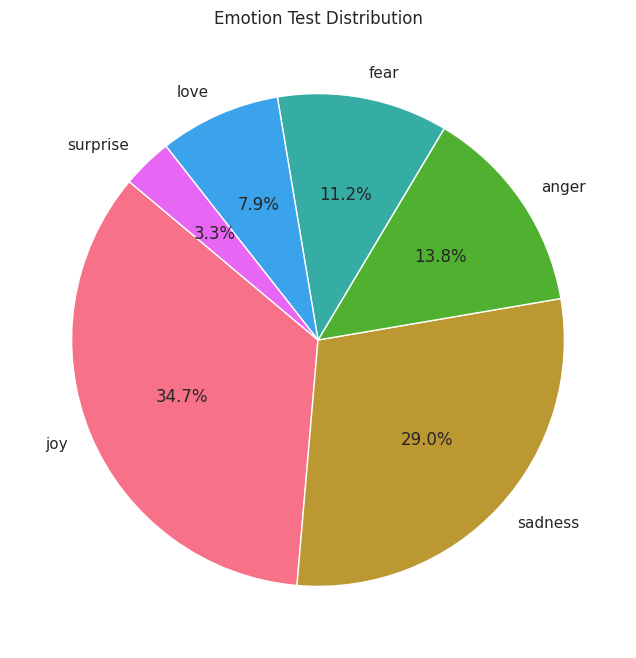

In [29]:
# Count label distributions
label_counts = ts_df['label'].value_counts()
light_colors = sns.husl_palette(n_colors=len(label_counts))
sns.set(style="whitegrid")
plt.figure(figsize=(8, 8))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=140, colors=light_colors)
plt.title('Emotion Test Distribution')
plt.show()

### 2.2 Data Exploration

Let's examine the structure and distribution of our datasets to understand the data better.

In [30]:
tr_text = df['sentence']
tr_label = df['label']

val_text = val_df['sentence']
val_label = val_df['label']

ts_text = ts_df['sentence']
ts_label = ts_df['label']

texts = df["sentence"].tolist()
labels = df["label"].tolist()

### 2.3 Label Encoding

Convert text labels to numerical values that the model can understand. We'll use LabelEncoder to map emotion strings to integers.

In [31]:
encoder = LabelEncoder()
df_label = encoder.fit_transform(tr_label)
val_df_label = encoder.transform(val_label)
ts_df_label = encoder.transform(ts_label)

## 3. Tokenization

We'll use the BERT tokenizer to convert text into tokens that Tranformer model can understand.

In [32]:
PRE_TRAINED_MODEL_NAME = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(PRE_TRAINED_MODEL_NAME)


### Choosing Sequence Length

BERT Transformer works with fixed-length sequences. We'll use a simple strategy to choose the max length. Let's store the token length of each review:

In [34]:
token_lens = []

for txt in df['sentence']:
  tokens = tokenizer.encode(txt, max_length=512, truncation=True)
  token_lens.append(len(tokens))

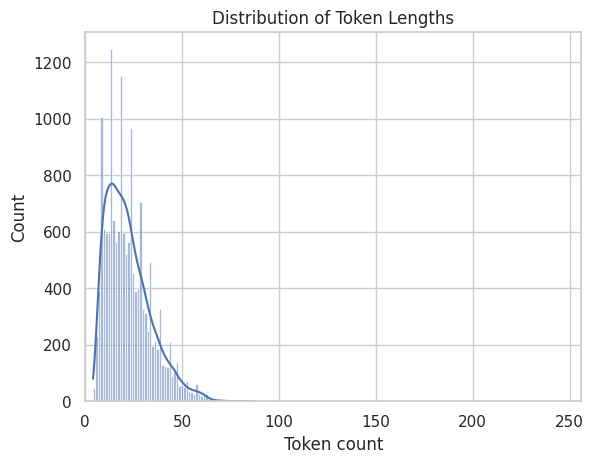

In [35]:
sns.histplot(token_lens, kde=True)
plt.xlim([0, 256])
plt.xlabel('Token count')
plt.title('Distribution of Token Lengths')
plt.show()

Most of the text samples contain less than 75 tokens. We'll set our maximum sequence length to 75 to capture most of the text while keeping computational efficiency.

### 3.1 Custom Dataset Class

We'll create a custom PyTorch Dataset class to handle our emotion data with proper tokenization.


In [36]:
MAX_LEN = 75

In [37]:
class GPReviewDataset(Dataset):

  def __init__(self, reviews, targets, tokenizer, max_len):
    self.reviews = reviews
    self.targets = targets
    self.tokenizer = tokenizer
    self.max_len = max_len
  
  def __len__(self):
    return len(self.reviews)
  
  def __getitem__(self, item):
    review = str(self.reviews[item])
    target = self.targets[item]

    encoding = self.tokenizer(
    review,
    add_special_tokens=True,
    max_length=self.max_len,
    padding='max_length',
    truncation=True,
    return_token_type_ids=False,
    return_attention_mask=True,
    return_tensors='pt'
    )
    
    return {
        'review_text': review,
        'input_ids': encoding['input_ids'].squeeze(0),      # shape (max_len,)
        'attention_mask': encoding['attention_mask'].squeeze(0),
        'targets': torch.tensor(target, dtype=torch.long)
    }


### 3.2 Data Loader Function

We'll create a function to generate data loaders for training, validation, and testing.

In [38]:
def create_data_loader(df, labels, tokenizer, max_len, batch_size):
  ds = GPReviewDataset(
    reviews=df['sentence'].tolist(),
    targets=labels, 
    tokenizer=tokenizer,
    max_len=max_len
  )

  return DataLoader(
    ds,
    batch_size=batch_size,
    num_workers=4
  )

In [39]:
BATCH_SIZE = 16

train_data_loader = create_data_loader(df, df_label, tokenizer, MAX_LEN, BATCH_SIZE)
val_data_loader = create_data_loader(val_df, val_df_label, tokenizer, MAX_LEN, BATCH_SIZE)
test_data_loader = create_data_loader(ts_df, ts_df_label, tokenizer, MAX_LEN, BATCH_SIZE)

### 3.3 Verify Data Loading

Let's examine a sample batch to ensure our data loading is working correctly.

In [40]:
data = next(iter(train_data_loader))
data.keys()

dict_keys(['review_text', 'input_ids', 'attention_mask', 'targets'])

In [41]:
print(data['input_ids'].shape)
print(data['attention_mask'].shape)
print(data['targets'].shape)

torch.Size([16, 75])
torch.Size([16, 75])
torch.Size([16])


## 4. Model Architecture

Now we'll build our emotion classifier using BERT as the backbone with a custom classification head.

### 4.1 Load Pre-trained BERT Model


In [42]:
bert_model = BertModel.from_pretrained(PRE_TRAINED_MODEL_NAME, return_dict=False)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

We create a classifier that uses the BERT model:

In [43]:
class SentimentClassifier(nn.Module):

  def __init__(self, n_classes):
    super(SentimentClassifier, self).__init__()
    self.bert = BertModel.from_pretrained(PRE_TRAINED_MODEL_NAME, return_dict=False)
    self.drop = nn.Dropout(p=0.3)
    self.out = nn.Linear(self.bert.config.hidden_size, n_classes)
  
  def forward(self, input_ids, attention_mask):
    _, pooled_output = self.bert(
      input_ids=input_ids,
      attention_mask=attention_mask
    )
    output = self.drop(pooled_output)
    return self.out(output)

Our classifier delegates most of the heavy lifting to the BertModel. We use a dropout layer for some regularization and a fully-connected layer for our output. We're returning the raw output of the last layer since that is required for the cross-entropy loss function in PyTorch to work.

In [44]:
n_classes = len(encoder.classes_)   # recommended
# n_classes = len(np.unique(tr_label))
model = SentimentClassifier(n_classes)
model = model.to(device)

## 5. Training

In [45]:
EPOCHS = 10

optimizer = AdamW(model.parameters(), lr=2e-5)
total_steps = len(train_data_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
  optimizer,
  num_warmup_steps=0,
  num_training_steps=total_steps
)

loss_fn = nn.CrossEntropyLoss().to(device)

In [46]:
def train_epoch(
  model, 
  data_loader, 
  loss_fn, 
  optimizer, 
  device, 
  scheduler, 
  n_examples
):
  model = model.train()

  losses = []
  correct_predictions = 0
  
  for d in data_loader:
    input_ids = d["input_ids"].to(device)
    attention_mask = d["attention_mask"].to(device)
    targets = d["targets"].to(device)

    outputs = model(
      input_ids=input_ids,
      attention_mask=attention_mask
    )

    _, preds = torch.max(outputs, dim=1)
    loss = loss_fn(outputs, targets)

    correct_predictions += torch.sum(preds == targets)
    losses.append(loss.item())

    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step()
    optimizer.zero_grad()

  return correct_predictions.double() / n_examples, np.mean(losses)

In [47]:
def eval_model(model, data_loader, loss_fn, device, n_examples):
  model = model.eval()

  losses = []
  correct_predictions = 0

  with torch.no_grad():
    for d in data_loader:
      input_ids = d["input_ids"].to(device)
      attention_mask = d["attention_mask"].to(device)
      targets = d["targets"].to(device)

      outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask
      )
      _, preds = torch.max(outputs, dim=1)

      loss = loss_fn(outputs, targets)

      correct_predictions += torch.sum(preds == targets)
      losses.append(loss.item())

  return correct_predictions.double() / n_examples, np.mean(losses)

Using above 2 methods, we write a training loop. We also store the training history.

In [48]:
%%time

history = defaultdict(list)
best_accuracy = 0

for epoch in range(EPOCHS):

  print(f'Epoch {epoch + 1}/{EPOCHS}')
  print('-' * 10)

  train_acc, train_loss = train_epoch(
    model,
    train_data_loader,    
    loss_fn, 
    optimizer, 
    device, 
    scheduler, 
    len(df)
  )

  print(f'Train loss {train_loss} accuracy {train_acc}')

  val_acc, val_loss = eval_model(
    model,
    val_data_loader,
    loss_fn, 
    device, 
    len(val_df)
  )

  print(f'Val   loss {val_loss} accuracy {val_acc}')
  print()

  history['train_acc'].append(train_acc.item())
  history['train_loss'].append(train_loss.item())
  history['val_acc'].append(val_acc.item())
  history['val_loss'].append(val_loss)

  best_accuracy = 0.0

  # inside loop, after val_acc computed (val_acc is a tensor scalar)
  if val_acc.item() > best_accuracy:
      torch.save(model.state_dict(), 'best_model_state.bin')
      best_accuracy = val_acc.item()

Epoch 1/10
----------
Train loss 0.5295521964658984 accuracy 0.8175
Val   loss 0.17179153390973806 accuracy 0.9400000000000001

Epoch 2/10
----------
Train loss 0.15470412251993548 accuracy 0.9410000000000001
Val   loss 0.20565689902659506 accuracy 0.9380000000000001

Epoch 3/10
----------
Train loss 0.10794051575992489 accuracy 0.9570000000000001
Val   loss 0.23063607041863723 accuracy 0.9425

Epoch 4/10
----------
Train loss 0.08659574445235194 accuracy 0.9678125000000001
Val   loss 0.27283477670466527 accuracy 0.9410000000000001

Epoch 5/10
----------
Train loss 0.0644700715043582 accuracy 0.9790625000000001
Val   loss 0.30109344209206756 accuracy 0.9375

Epoch 6/10
----------
Train loss 0.04625213626530603 accuracy 0.9872500000000001
Val   loss 0.36832603233354166 accuracy 0.9345

Epoch 7/10
----------
Train loss 0.03355043014604598 accuracy 0.9908125
Val   loss 0.34767358748812693 accuracy 0.9380000000000001

Epoch 8/10
----------
Train loss 0.024725597070726506 accuracy 0.993625


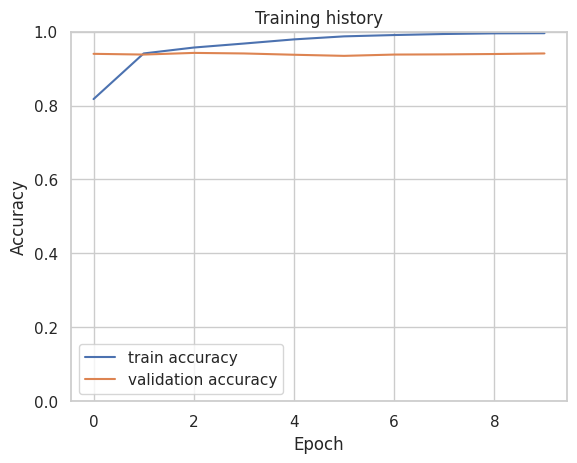

In [49]:
def to_float(x):
    if hasattr(x, "item"):   # torch.Tensor
        return x.item()
    return float(x)          # already float

train_acc = [to_float(acc) for acc in history['train_acc']]
val_acc   = [to_float(acc) for acc in history['val_acc']]


plt.plot(train_acc, label='train accuracy')
plt.plot(val_acc, label='validation accuracy')

plt.title('Training history')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.ylim([0, 1])
plt.show()


## 6. Evaluation

In [50]:
test_acc, _ = eval_model(
  model,
  test_data_loader,
  loss_fn,
  device,
  len(ts_df)
)

test_acc.item()

0.9295

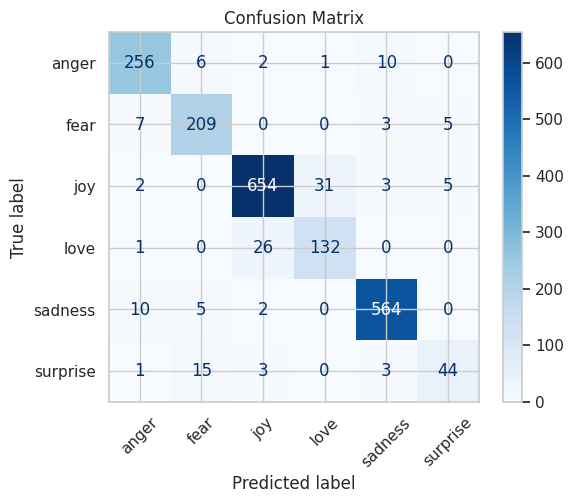

Classification Report:

              precision    recall  f1-score   support

       anger       0.92      0.93      0.93       275
        fear       0.89      0.93      0.91       224
         joy       0.95      0.94      0.95       695
        love       0.80      0.83      0.82       159
     sadness       0.97      0.97      0.97       581
    surprise       0.81      0.67      0.73        66

    accuracy                           0.93      2000
   macro avg       0.89      0.88      0.88      2000
weighted avg       0.93      0.93      0.93      2000



In [51]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- Collect predictions and true labels from test set ---
y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for d in test_data_loader:
        input_ids = d["input_ids"].to(device)
        attention_mask = d["attention_mask"].to(device)
        targets = d["targets"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        _, preds = torch.max(outputs, dim=1)

        y_true.extend(targets.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# --- Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encoder.classes_)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

# --- Precision, Recall, F1 ---
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=encoder.classes_))


## 7. Prediction Examples

Running inference on a few example sentences.


In [52]:
review_text = "I am so depressed"

encoded_review = tokenizer(
  review_text,
  max_length=MAX_LEN,
  add_special_tokens=True,
  return_token_type_ids=False,
  padding='max_length',
  truncation=True,
  return_attention_mask=True,
  return_tensors='pt',
)

input_ids = encoded_review['input_ids'].to(device)
attention_mask = encoded_review['attention_mask'].to(device)

class_names = ['sadness', 'anger', 'love', 'surprise', 'fear', 'joy']

output = model(input_ids, attention_mask)
_, prediction = torch.max(output, dim=1)

print(f'Review text: {review_text}')
pred_label = prediction.item()

# use LabelEncoder to get actual label string
predicted_label = encoder.inverse_transform([pred_label])[0]
print(f"Predicted emotion: {predicted_label}")


Review text: I am so depressed
Predicted emotion: sadness


In [53]:
review_text = "I am very happy to see you"

encoded_review = tokenizer(
  review_text,
  max_length=MAX_LEN,
  add_special_tokens=True,
  return_token_type_ids=False,
  padding='max_length',
  truncation=True,
  return_attention_mask=True,
  return_tensors='pt',
)


input_ids = encoded_review['input_ids'].to(device)
attention_mask = encoded_review['attention_mask'].to(device)

class_names = ['sadness', 'anger', 'love', 'surprise', 'fear', 'joy']

output = model(input_ids, attention_mask)
_, prediction = torch.max(output, dim=1)

print(f'Review text: {review_text}')
pred_label = prediction.item()

# use LabelEncoder to get actual label string
predicted_label = encoder.inverse_transform([pred_label])[0]
print(f"Predicted emotion: {predicted_label}")


Review text: I am very happy to see you
Predicted emotion: joy


In [54]:
review_text = "Wow that is amazing"

encoded_review = tokenizer(
  review_text,
  max_length=MAX_LEN,
  add_special_tokens=True,
  return_token_type_ids=False,
  padding='max_length',
  truncation=True,
  return_attention_mask=True,
  return_tensors='pt',
)


input_ids = encoded_review['input_ids'].to(device)
attention_mask = encoded_review['attention_mask'].to(device)

class_names = ['sadness', 'anger', 'love', 'surprise', 'fear', 'joy']

output = model(input_ids, attention_mask)
_, prediction = torch.max(output, dim=1)

print(f'Review text: {review_text}')
pred_label = prediction.item()

# use LabelEncoder to get actual label string
predicted_label = encoder.inverse_transform([pred_label])[0]
print(f"Predicted emotion: {predicted_label}")


Review text: Wow that is amazing
Predicted emotion: surprise


In [55]:
review_text = "I am afraid to be alone"

encoded_review = tokenizer(
  review_text,
  max_length=MAX_LEN,
  add_special_tokens=True,
  return_token_type_ids=False,
  padding='max_length',
  truncation=True,
  return_attention_mask=True,
  return_tensors='pt',
)


input_ids = encoded_review['input_ids'].to(device)
attention_mask = encoded_review['attention_mask'].to(device)

class_names = ['sadness', 'anger', 'love', 'surprise', 'fear', 'joy']

output = model(input_ids, attention_mask)
_, prediction = torch.max(output, dim=1)

print(f'Review text: {review_text}')
pred_label = prediction.item()

# use LabelEncoder to get actual label string
predicted_label = encoder.inverse_transform([pred_label])[0]
print(f"Predicted emotion: {predicted_label}")


Review text: I am afraid to be alone
Predicted emotion: fear
